## PyTorch Classification with Neural Network


In [1]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt


Create synthetic classification data


In [2]:
torch.manual_seed(42)

n_samples = 1500
X = torch.randn(n_samples, 2)
y = ((0.8 * X[:, 0] + 1.1 * X[:, 1]) > 0).float().unsqueeze(1)

split = int(0.8 * n_samples)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64)

print(X_train.shape, y_train.shape)


torch.Size([1200, 2]) torch.Size([1200, 1])


Build model, train, and evaluate


In [3]:
model = nn.Sequential(
    nn.Linear(2, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
    nn.Sigmoid()
)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

history = []
for epoch in range(30):
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    history.append(epoch_loss / len(train_loader))

model.eval()
with torch.no_grad():
    test_pred = model(X_test)
    test_acc = ((test_pred > 0.5).float() == y_test).float().mean().item()

print(f"Test accuracy: {test_acc:.4f}")


Test accuracy: 0.9967


Plot training loss


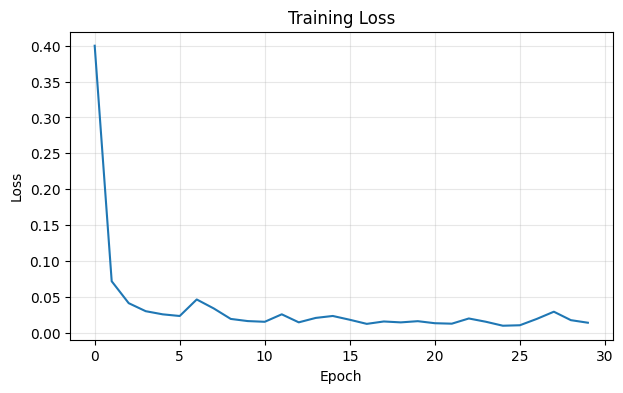

In [4]:
plt.figure(figsize=(7, 4))
plt.plot(history)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.show()
